In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *

2026-06-26 14:57:22.472263: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-26 14:57:22.542597: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-26 14:57:24.836110: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
file = "data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [3]:
data = dp.extract_dataframe(master_df)
index = data[0]  # SN Name for each spectrum
wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

## using ABC-SN to make predictions


In [4]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)

# need manually compile, using the code from ABC-SN/code/abcsn_training 
loss = keras.losses.CategoricalCrossentropy()
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
lr0_transfer=1e-5
optimizer = keras.optimizers.Nadam(learning_rate=lr0_transfer)
abcsn.compile(loss=loss, optimizer=optimizer, metrics=[acc, f1])

2026-06-26 14:57:27.724852: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

# predict type
P = abcsn.predict(X, verbose=0)
P_argmax = np.argmax(P, axis=1)

master_df["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
master_df["Pred_Mill_ID"] = P_Mill


2026-06-26 14:57:28.317765: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Checking various types

In [41]:
# Looking at milligan id counts
np.unique(P_argmax, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 723,  814, 1148,  844, 2619,  472, 2254, 2022, 2164,  383]))

In [ ]:
np.unique(P_Mill, return_counts=True)

In [7]:
master_df[["ABC_type", "Mill_type", "sn_type"]].dropna().groupby(["ABC_type", "Mill_type"]).first()

,,sn_type
ABC_type,Mill_type,
0.0,0.0,Ia
1.0,0.0,Iap
4.0,1.0,Ib
6.0,1.0,IIb
7.0,1.0,Ic
9.0,2.0,II


# Looking at the results of prediction with ABCSN labels

In [8]:
Y_ABC_IDs = master_df.ABC_type.values
index = ~np.isnan(Y_ABC_IDs)

cr = (classification_report(
    Y_ABC_IDs[index],
    P_argmax[index],
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)
#may be skewed 

              precision    recall  f1-score   support

     Ia-norm       0.91      0.08      0.14      8074
      Ia-91T       0.02      0.06      0.03       263
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.02      0.17      0.03       262
         Ibn       0.00      0.00      0.00         0
         IIb       0.05      0.17      0.08       542
     Ic-norm       0.02      0.21      0.04       193
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.07      0.01      0.02      1819

    accuracy                           0.08     11153
   macro avg       0.11      0.07      0.04     11153
weighted avg       0.67      0.08      0.11     11153



/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [9]:
np.unique(Y_ABC_IDs, return_counts=True)
# what changed between the 9s and nans 

(array([ 0.,  1.,  4.,  6.,  7.,  9., nan]),
 array([8074,  263,  262,  542,  193, 1819, 2290]))

In [16]:
ABC_ID_dict = get_ABC_ID_dict()

/lustre/lrspec/users/4301/Milligan_ABC-SN/plot_data.py:13: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


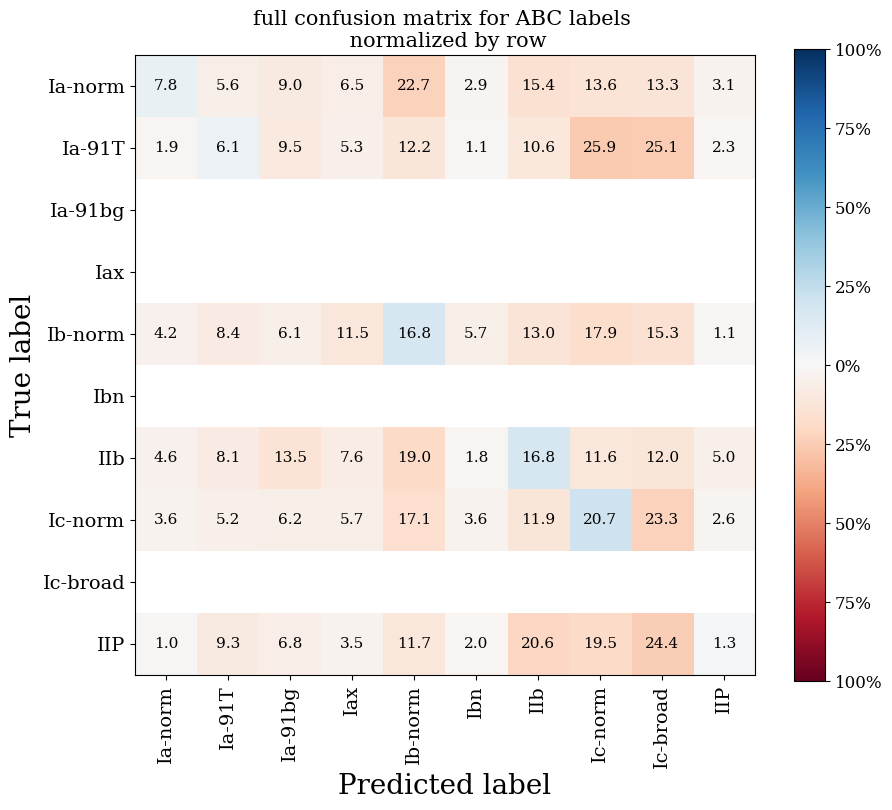

In [15]:
ABC_ID_dict = get_ABC_ID_dict()

index = ~np.isnan(Y_ABC_IDs)
cm = confusion_matrix(master_df.ABC_type.values[index], 
                      master_df.Pred_ABC_ID.values[index])
plot = plot_cm(cm, list(ABC_ID_dict.values()), 
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

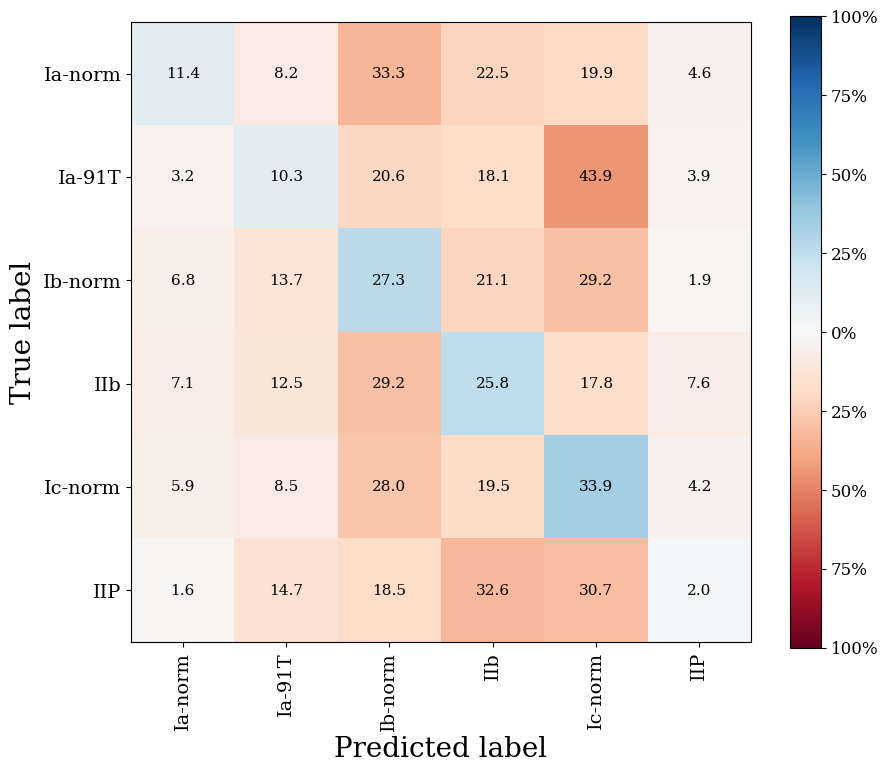

In [21]:
# truncated confusion matrix for ABC labels
truncated_labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)[:-1]]
## note last one is removed because it is nan

cm = confusion_matrix(master_df.ABC_type.values[index], master_df.Pred_ABC_ID.values[index], 
                           labels=np.unique(Y_ABC_IDs)[:-1])
plot = plot_cm(cm, truncated_labels)

## look at various normalizations

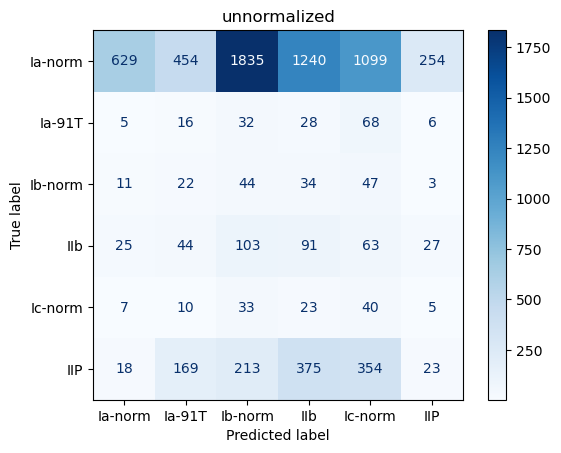

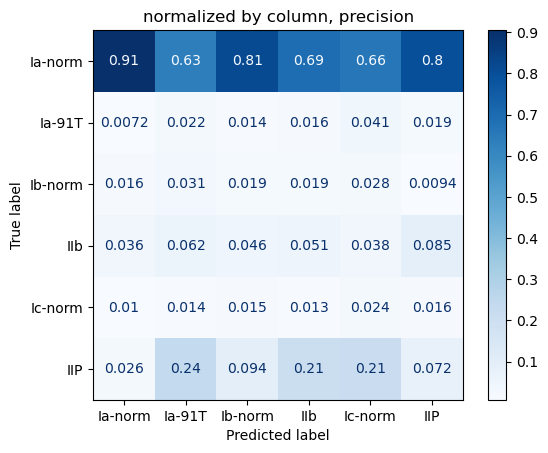

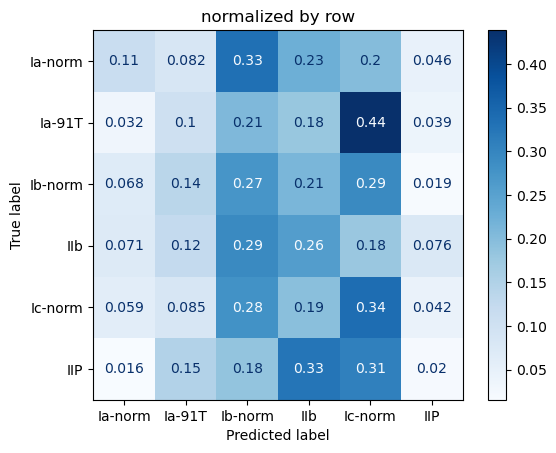

In [30]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(master_df.ABC_type.values[index], 
                          master_df.Pred_ABC_ID.values[index], 
                          labels=np.unique(Y_ABC_IDs)[:-1],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=truncated_labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

## Looking at close and bright SN objects

In [28]:
SN_index = ~np.isnan(Y_ABC_IDs)
SN_df = master_df[index].copy()
brighter_SN_index = SN_df.host_mag > SN_df.SN_mag + 1
small_z_index = SN_df.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = SN_df[bright_close_index].copy()

131


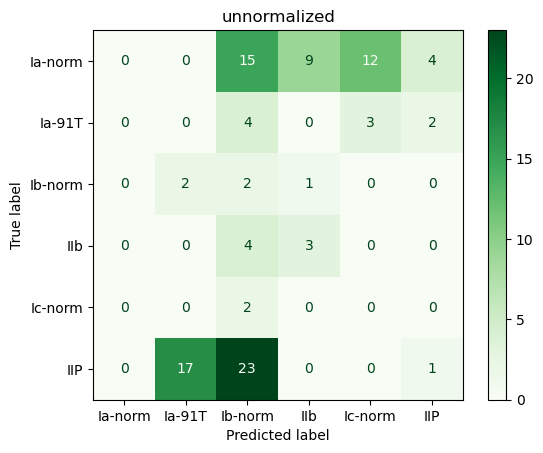

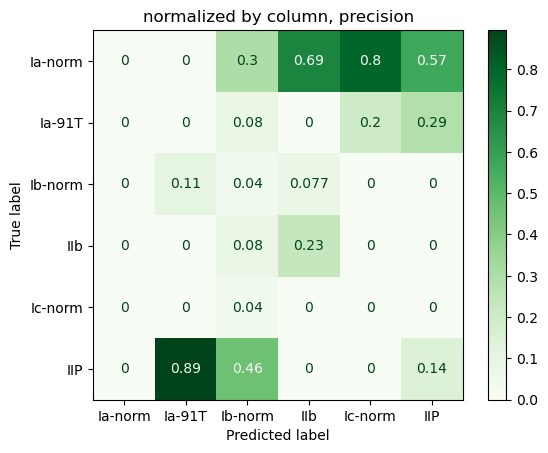

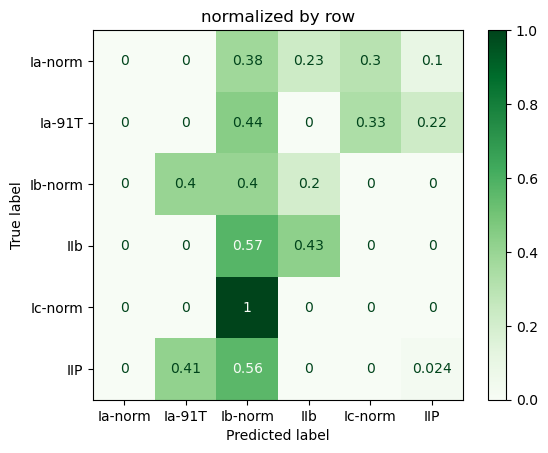

In [33]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values, 
                          bright_close_SN_df.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:-1],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=truncated_labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

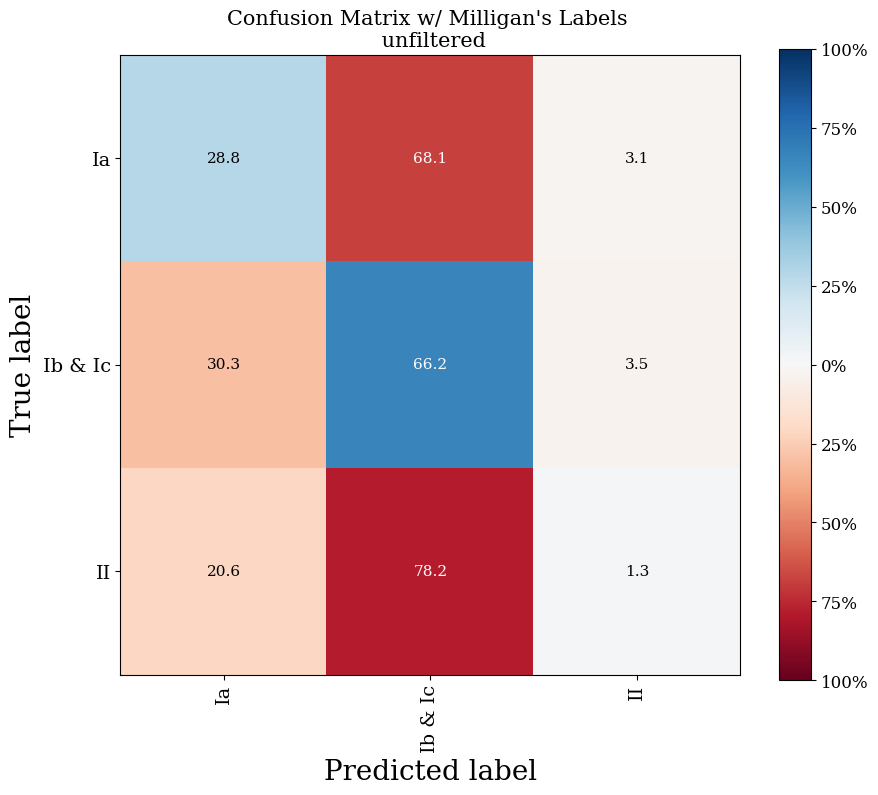

In [34]:

cm_mill = confusion_matrix(SN_df.Mill_type, SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

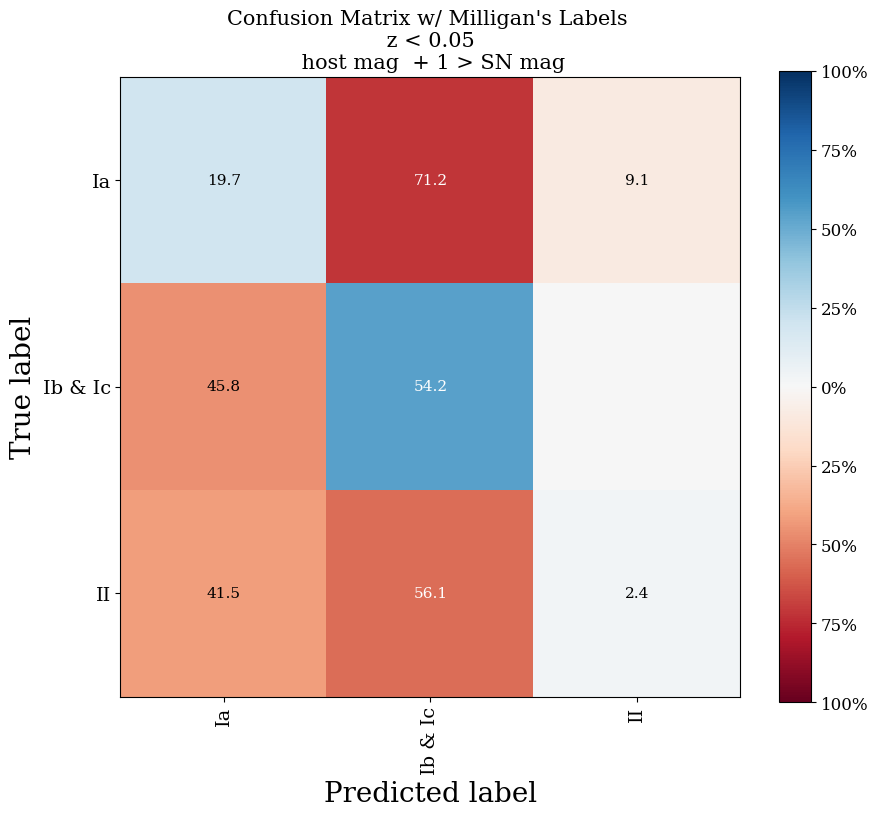

In [36]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra

/tmp/ipykernel_46217/827850364.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


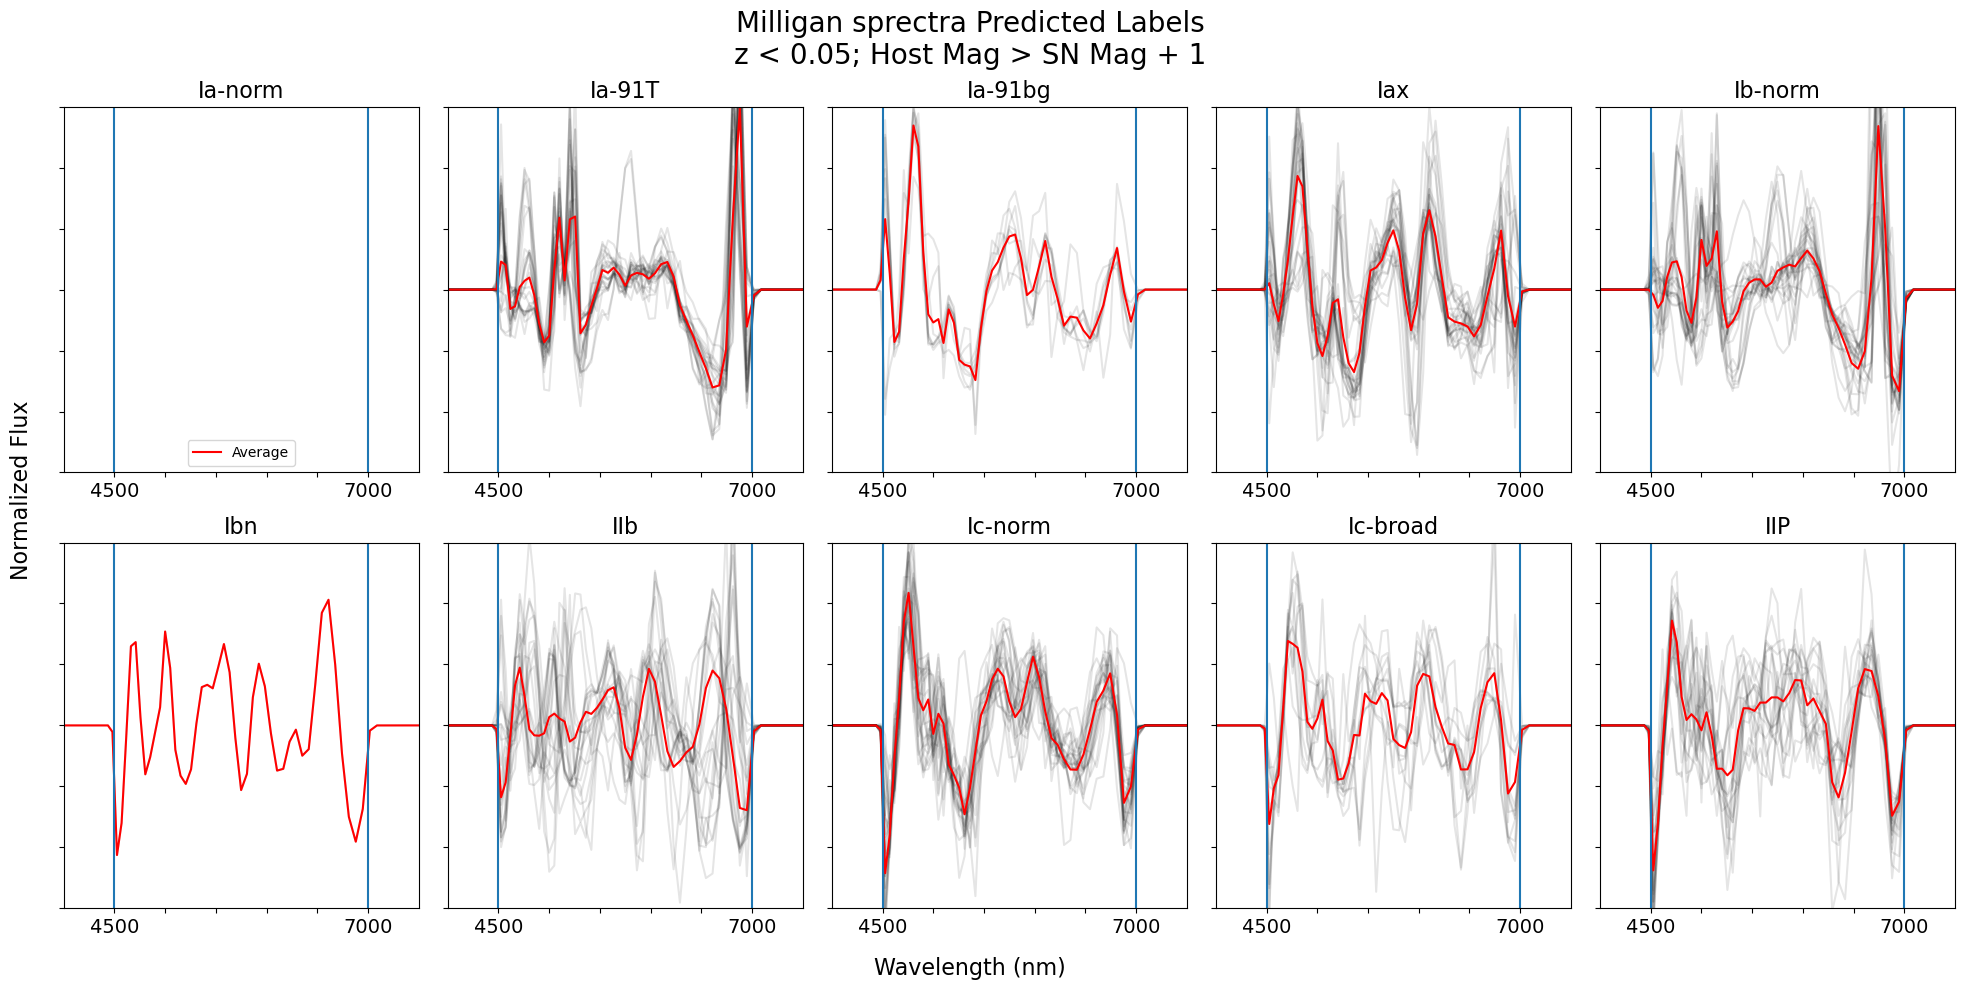

In [40]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = master_df.host_mag > master_df.SN_mag +1
small_z_index = master_df.redshift < 0.05
close_bright_df = master_df[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
